In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# S1

In [ ]:
manifold_type = 'S1'; manifold = get_manifold(manifold_type)

n_samples_ls = [100, 500, 1000, 2500, 5000, 7500, 10000]
G =  get_G_class(manifold_type, multimodal_sampler, '2-modal', {'tau2' : 0.05, 'num_modes' : 2})
# G = get_G_class(manifold_type, equator_sampler, 'equator', {'tau2' : 0.001})
# G = get_G_class(manifold_type, uniform_sampler, 'uniform', {})

sigma2 = 0.1

NMC = 5

test_size = 1000
num_oracle_samples = 10000

M = 6
rho = 1e-2


In [4]:
df_rate = converenge_rate_experiment( manifold_type, G, n_samples_ls, M, rho, sigma2, test_size, num_oracle_samples, NMC)

,num_samples,M,rho,mean_excess_loss,mean_displacement
0,100,6,0.01,0.047976,0.049032
1,500,6,0.01,0.012158,0.018219
2,1000,6,0.01,0.018078,0.019964
3,2500,6,0.01,0.000857,0.003807
4,5000,6,0.01,-0.000391,0.002703
5,7500,6,0.01,0.000228,0.002682
6,10000,6,0.01,-0.000477,0.002394


/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_13587/263983596.py:25: RuntimeWarning: invalid value encountered in log
  b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)


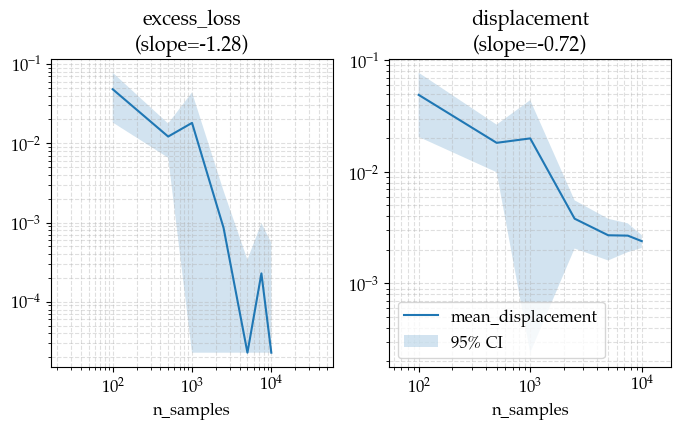

In [7]:
if True:
    fig, axs = plt.subplots(figsize=(8,4), ncols = 2, sharey = False)
    if 'M_star' in df_rate.columns:
        display(df_rate.sort_values("num_samples")[['num_samples', 'M_star', 'rho_star', 'mean_excess_loss', 'mean_displacement']])
    else:
        display(df_rate.sort_values("num_samples")[['num_samples', 'M', 'rho', 'mean_excess_loss', 'mean_displacement']])
    for variable, ax in zip( [ 'excess_loss', 'displacement'], axs):
        df_rec = df_rate.sort_values("num_samples").copy()
        # df_rec['mean_excess_loss'] = df_rec['mean_emp_loss'] -  (df_rec['mean_oracle_loss'] - df_rec['std_oracle_loss'])
        x = df_rec["num_samples"].to_numpy(dtype=float)
        y = df_rec["mean_" + variable].to_numpy(dtype=float)
        ci  = 1.96 * df_rec["std_" + variable].to_numpy(dtype=float) / np.sqrt(NMC)

        # avoid log(0) / negative values
        eps = y[y > 0].min()/10 
        y_plot = np.clip(y, eps, None); y_lo = np.clip(y - ci, eps, None); y_hi = np.clip(y + ci, eps, None)
        ax.plot(x, y_plot,label="mean_displacement")
        ax.fill_between(x, y_lo, y_hi, alpha=0.2, label="95% CI")

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("n_samples")
        ax.grid(True, which="both", ls="--", alpha=0.4)

        # fit in log-log space: log(y) = a + b*log(x)
        b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)
        ax.set_title(f"{variable}\n(slope={b:.2f})")
        ax.set_aspect("equal", adjustable="datalim")

    plt.legend()
    plt.show()


# S2

In [9]:
manifold_type = 'S2'; manifold = get_manifold(manifold_type)

n_samples_ls = [100, 500, 1000, 2500, 5000, 7500, 10000]

G = get_G_class(manifold_type, equator_sampler, 'equator', {'tau2' : 0.001})

sigma2 = 0.1


NMC = 5

test_size = 1000
num_oracle_samples = 5000

M = 6
rho = 1e-3

In [10]:
df_rate = converenge_rate_experiment( manifold_type, G, n_samples_ls, M, rho, sigma2, test_size, num_oracle_samples, NMC)

,num_samples,M,rho,mean_excess_loss,mean_displacement
0,100,6,0.001,0.168463,0.185003
1,500,6,0.001,0.075559,0.087652
2,1000,6,0.001,0.067917,0.081677
3,2500,6,0.001,0.048284,0.064041
4,5000,6,0.001,0.062171,0.076873
5,7500,6,0.001,0.054809,0.076109
6,10000,6,0.001,0.073257,0.093144


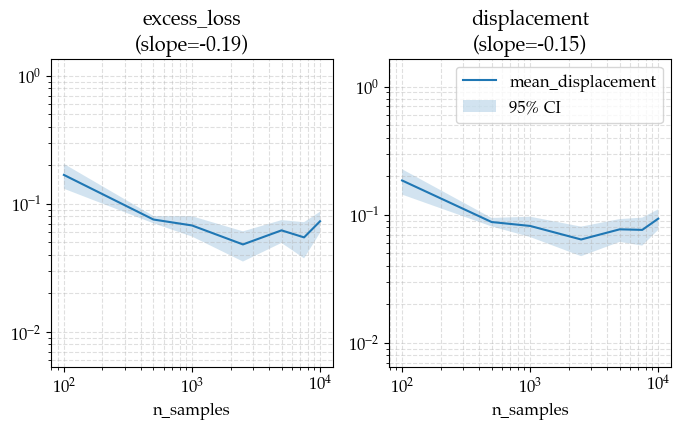

In [16]:
if True:
    fig, axs = plt.subplots(figsize=(8,4), ncols = 2, sharey = False)
    if 'M_star' in df_rate.columns:
        display(df_rate.sort_values("num_samples")[['num_samples', 'M_star', 'rho_star', 'mean_excess_loss', 'mean_displacement']])
    else:
        display(df_rate.sort_values("num_samples")[['num_samples', 'M', 'rho', 'mean_excess_loss', 'mean_displacement']])
    for variable, ax in zip( [ 'excess_loss', 'displacement'], axs):
        df_rec = df_rate.sort_values("num_samples").copy()
        # df_rec['mean_excess_loss'] = df_rec['mean_emp_loss'] -  (df_rec['mean_oracle_loss'] - df_rec['std_oracle_loss'])
        x = df_rec["num_samples"].to_numpy(dtype=float)
        y = df_rec["mean_" + variable].to_numpy(dtype=float)
        ci  = 1.96 * df_rec["std_" + variable].to_numpy(dtype=float) / np.sqrt(NMC)

        # avoid log(0) / negative values
        eps = y[y > 0].min()/10 
        y_plot = np.clip(y, eps, None); y_lo = np.clip(y - ci, eps, None); y_hi = np.clip(y + ci, eps, None)
        ax.plot(x, y_plot,label="mean_displacement")
        ax.fill_between(x, y_lo, y_hi, alpha=0.2, label="95% CI")

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("n_samples")
        ax.grid(True, which="both", ls="--", alpha=0.4)

        # fit in log-log space: log(y) = a + b*log(x)
        b, a = np.polyfit(np.log(x)[np.log(y) == np.log(y)], np.log(y)[np.log(y) == np.log(y)], 1)
        ax.set_title(f"{variable}\n(slope={b:.2f})")
        ax.set_aspect("equal", adjustable="datalim")

    plt.legend()
    plt.show()